# Example Usage

## Create a fake novelty function

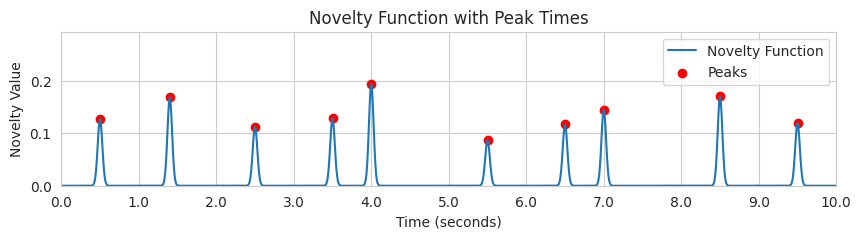

In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Define a pseudo novelty function
Fs = 100    # Sampling frequency of the novelty function
x = np.zeros(Fs * 10)  # 10 seconds of zeros
peaks_sec = [0.5, 1.4, 2.5, 3.5, 4, 5.5, 6.5, 7.0, 8.5, 9.5]  # Peak locations in seconds
peaks_idx = np.array([int(sec * Fs) for sec in peaks_sec])  # Peak locations in samples
x[peaks_idx] = 0.5 + np.random.rand(len(peaks_idx))  # Set the peaks to 1
# Apply Gaussian filter to the novelty function
x = gaussian_filter1d(x, sigma=3)

# Plot the novelty function and the peak times
plt.figure(figsize=(10, 2))
plt.plot(x, label='Novelty Function')
plt.scatter(peaks_idx, x[peaks_idx], color='red', label='Peaks')  # Peaks
plt.xlim(0, Fs * 10)
plt.ylim(0, max(x) + 0.1)
plt.xticks(ticks=np.arange(0, 10 * Fs+1, Fs), labels=np.arange(0, 10.01, 1))  # Change the x-axis ticks from x indices to seconds
plt.xlabel('Time (seconds)')
plt.ylabel('Novelty Value')
plt.title('Novelty Function with Peak Times')
plt.legend()
plt.show()

## Detect peaks

Estimated peak times:  0.50, 1.40, 2.50, 3.50, 4.00, 5.50, 6.50, 7.00, 8.50, 9.50


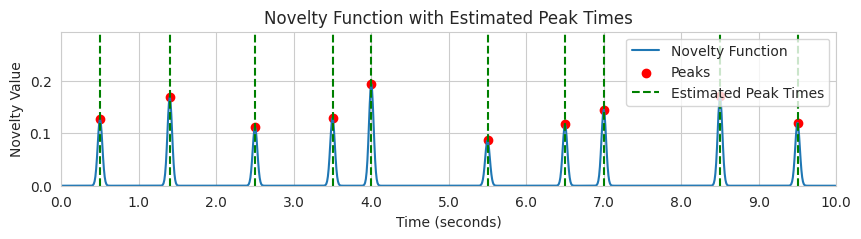

In [2]:
# Add ../ to the path
import sys
sys.path.append('../')

from peak_picking.loc import detect_peaks_loc

est = detect_peaks_loc(x, Fs, win_sec=10)

# Print the estimated peak times
print('Estimated peak times: ', ', '.join([f'{t:.2f}' for t in est]))

# Plot the novelty function and the peak times
plt.figure(figsize=(10, 2))
plt.plot(x, label='Novelty Function')
plt.scatter(peaks_idx, x[peaks_idx], color='red', label='Peaks')  # Peaks
plt.vlines(est * Fs, 0, max(x)+0.1, color='green', label='Estimated Peak Times', linestyle='--')  # Estimated peaks
plt.xlim(0, Fs * 10)
plt.ylim(0, max(x) + 0.1)
plt.xticks(ticks=np.arange(0, 10 * Fs+1, Fs), labels=np.arange(0, 10.01, 1))  # Change the x-axis ticks from x indices to seconds
plt.xlabel('Time (seconds)')
plt.ylabel('Novelty Value')
plt.title('Novelty Function with Estimated Peak Times')
plt.legend()
plt.show()